In [1]:
'''

        IMPORTANT NOTE:I used to AI in some parts. For example for write explanation of code.In addition in some code parts I used to AI and 
        will mention it

'''

'\n\n        IMPORTANT NOTE:I used to AI in some parts. For example for write explanation of code.In addition in some code parts I used to AI and \n        will mention it\n\n'

In [2]:

#Project Overview
#This project implements a comprehensive machine learning pipeline to predict whether
#it will rain tomorrow based on historical weather observations. 
#The analysis begins by loading training and test datasets from CSV files, 
#followed by thorough data preprocessing including handling missing values,
#removing columns with excessive null counts, 
#and validating data ranges to ensure realistic weather measurements. 
#The target variable is RainTomorrow, a binary classification problem where 0 indicates no rain and 1 indicates rain.


In [3]:

#I've added a concise documentation section for Cell 1 at the beginning of your document. It explains the purpose of each imported library in a single paragraph and includes the code block. The documentation covers:

#- **Data handling**: Pandas and NumPy
#- **Model utilities**: train_test_split and StandardScaler
#- **Evaluation metrics**: accuracy, classification report, and confusion matrix
#- **Algorithms**: Logistic Regression, K-Nearest Neighbors, and Random Forest

#This format keeps the documentation brief while providing enough context for someone to understand what each import will be used for in the project.


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [5]:
train_df = pd.read_csv("C:/Users/Emil/Desktop/Subjects/ASOIU/IV course/I Term/Data Analyst/The Last Project/Train_data.csv")
test_df = pd.read_csv("C:/Users/Emil/Desktop/Subjects/ASOIU/IV course/I Term/Data Analyst/The Last Project/Test_data.csv")

In [6]:
#The primary purpose of this section is to prepare the raw data for analysis
#and model building by loading it into the Python environment using the pandas library.'''

In [7]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89564 entries, 0 to 89563
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     89564 non-null  int64  
 1   Location       89564 non-null  object 
 2   MinTemp        89174 non-null  float64
 3   MaxTemp        89365 non-null  float64
 4   Rainfall       88675 non-null  float64
 5   Evaporation    51319 non-null  float64
 6   Sunshine       47010 non-null  float64
 7   WindGustDir    83700 non-null  object 
 8   WindGustSpeed  83741 non-null  float64
 9   WindDir9am     83256 non-null  object 
 10  WindDir3pm     87182 non-null  object 
 11  WindSpeed9am   88725 non-null  float64
 12  WindSpeed3pm   87911 non-null  float64
 13  Humidity9am    88468 non-null  float64
 14  Humidity3pm    87307 non-null  float64
 15  Pressure9am    80788 non-null  float64
 16  Pressure3pm    80799 non-null  float64
 17  Cloud9am       55708 non-null  float64
 18  Cloud3

In [8]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9952 entries, 0 to 9951
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     9952 non-null   int64  
 1   Location       9952 non-null   object 
 2   MinTemp        9899 non-null   float64
 3   MaxTemp        9921 non-null   float64
 4   Rainfall       9862 non-null   float64
 5   Evaporation    5666 non-null   float64
 6   Sunshine       5189 non-null   float64
 7   WindGustDir    9295 non-null   object 
 8   WindGustSpeed  9295 non-null   float64
 9   WindDir9am     9254 non-null   object 
 10  WindDir3pm     9686 non-null   object 
 11  WindSpeed9am   9856 non-null   float64
 12  WindSpeed3pm   9770 non-null   float64
 13  Humidity9am    9815 non-null   float64
 14  Humidity3pm    9703 non-null   float64
 15  Pressure9am    8980 non-null   float64
 16  Pressure3pm    8981 non-null   float64
 17  Cloud9am       6236 non-null   float64
 18  Cloud3pm

In [9]:
'''
This code snippet is used for quickly assessing the data quality by calculating and 
displaying the total number of missing values (NaN) in each column of the train_df DataFrame.
'''

'\nThis code snippet is used for quickly assessing the data quality by calculating and \ndisplaying the total number of missing values (NaN) in each column of the train_df DataFrame.\n'

In [10]:
column_nan_count = train_df.isnull().sum()
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
Unnamed: 0           0
Location             0
MinTemp            390
MaxTemp            199
Rainfall           889
Evaporation      38245
Sunshine         42554
WindGustDir       5864
WindGustSpeed     5823
WindDir9am        6308
WindDir3pm        2382
WindSpeed9am       839
WindSpeed3pm      1653
Humidity9am       1096
Humidity3pm       2257
Pressure9am       8776
Pressure3pm       8765
Cloud9am         33856
Cloud3pm         36029
Temp9am            545
Temp3pm           1714
RainToday          889
RainTomorrow         0
dtype: int64


In [11]:
column_nan_count = test_df.isnull().sum()
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
Unnamed: 0          0
Location            0
MinTemp            53
MaxTemp            31
Rainfall           90
Evaporation      4286
Sunshine         4763
WindGustDir       657
WindGustSpeed     657
WindDir9am        698
WindDir3pm        266
WindSpeed9am       96
WindSpeed3pm      182
Humidity9am       137
Humidity3pm       249
Pressure9am       972
Pressure3pm       971
Cloud9am         3716
Cloud3pm         3973
Temp9am            69
Temp3pm           190
RainToday          90
dtype: int64


In [12]:
# ---------------------------------------------------------
# DROP UNNECESSARY COLUMNS
# These columns are removed due to high missing values
# or low contribution to the prediction task
# ---------------------------------------------------------
train_df = train_df.drop(columns=['Evaporation', 'Sunshine','Cloud9am','Cloud3pm'])
test_df = test_df.drop(columns=['Evaporation', 'Sunshine','Cloud9am','Cloud3pm'])

In [13]:
# ---------------------------------------------------------
# REMOVE UNUSED INDEX COLUMN
# "Unnamed: 0" is an automatically created index column
# and has no predictive value
# ---------------------------------------------------------
train_df = train_df.drop(columns=['Unnamed: 0'])
test_df = test_df.drop(columns=['Unnamed: 0'])

In [14]:
# ---------------------------------------------------------
# IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# Numerical columns will be treated differently from
# categorical columns during missing value handling
# ---------------------------------------------------------
num_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()
# ---------------------------------------------------------
# CALCULATE SKEWNESS FOR NUMERICAL FEATURES
# Skewness helps decide whether to use mean or median
# ---------------------------------------------------------
skew_vals = train_df[num_cols].skew()

# ---------------------------------------------------------
# HANDLE MISSING VALUES IN NUMERICAL COLUMNS
# - If data is skewed (|skew| > 0.5) → use MEDIAN
# - Otherwise → use MEAN
# Same values are applied to train and test data
# to avoid data leakage
# ---------------------------------------------------------
for col in num_cols:
    # Use median if data is skewed, otherwise use mean
    if abs(skew_vals[col]) > 0.5:
        fill_val = train_df[col].median()
    else:
        fill_val = train_df[col].mean()
    
    train_df[col] = train_df[col].fillna(fill_val)
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(fill_val)

# ---------------------------------------------------------
# HANDLE MISSING VALUES IN CATEGORICAL COLUMNS
# Missing values are filled using the most frequent value (mode)
# from the training dataset
# ---------------------------------------------------------
for col in cat_cols:
    fill_val = train_df[col].mode()[0]
    train_df[col] = train_df[col].fillna(fill_val)
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(fill_val)


In [15]:
column_nan_count = train_df.isnull().sum()
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64


In [16]:
column_nan_count = test_df.isnull().sum()
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
dtype: int64


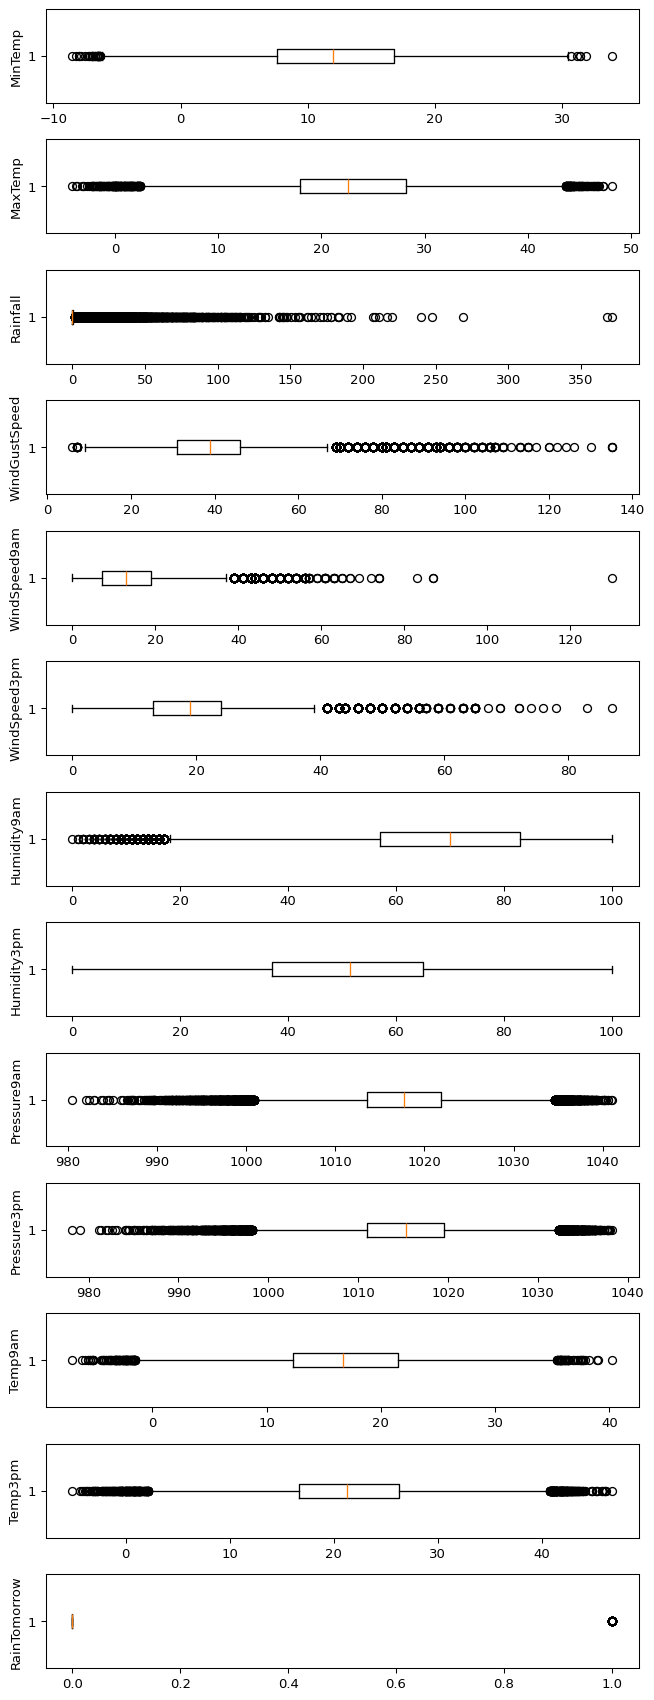

In [17]:
# Create boxplots for all numerical features to visually analyze their distribution,
# detect outliers, and observe data spread. Missing values are dropped only for
# visualization purposes, and horizontal boxplots are used to improve readability
# when plotting multiple features.
import matplotlib.pyplot as plt

fig, axs = plt.subplots(len(num_cols), 1, figsize=(7, 18), dpi=95)

for i, col in enumerate(num_cols):
    axs[i].boxplot(train_df[col].dropna(), vert=False)  # drop NaN for plotting
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [18]:

    #In this part I use helping of AI. So, I read that If we do weather condition model.
    #We usually have extrem condition and It can assume as outlier but we shouldn't do that.
    #Therefore I will delete or handle only unrealistic values. 
    #For example temperature can not be greater 60C but it can be 30 40. 
    #Therefore I will detect only impossible situations


In [19]:
# ---------------------------------------------------------
# LOAD TRAIN AND TEST DATASETS
# ---------------------------------------------------------
train = pd.read_csv(
    "C:/Users/Emil/Desktop/Subjects/ASOIU/IV course/I Term/Data Analyst/The Last Project/Train_data.csv"
)
test = pd.read_csv(
    "C:/Users/Emil/Desktop/Subjects/ASOIU/IV course/I Term/Data Analyst/The Last Project/Test_data.csv"
)

# ---------------------------------------------------------
# COMBINE TRAIN AND TEST DATA
# This is done only for validation checks (not modeling)
# ---------------------------------------------------------
data = pd.concat([train, test], axis=0)

print("Checking impossible values...\n")

# ---------------------------------------------------------
# DEFINE REALISTIC VALUE RANGES FOR WEATHER FEATURES
# These rules are based on physical and meteorological limits
# ---------------------------------------------------------
rules = {
    "Rainfall": (0, None),        # rainfall cannot be negative
    "Rainfall9am": (0, None),
    "Rainfall3pm": (0, None),

    "Humidity9am": (0, 100),     # humidity is a percentage
    "Humidity3pm": (0, 100),

    "WindSpeed9am": (0, None),   # wind speed cannot be negative
    "WindSpeed3pm": (0, None),

    "WindGustSpeed": (0, None),

    "Pressure9am": (900, 1100),  # typical atmospheric pressure (hPa)
    "Pressure3pm": (900, 1100),

    "Temp9am": (-20, 60),        # realistic temperature limits
    "Temp3pm": (-20, 60),
    "MinTemp": (-20, 60),
    "MaxTemp": (-20, 60)
}

# ---------------------------------------------------------
# FUNCTION TO CHECK RANGE VIOLATIONS
# Returns rows below or above allowed limits
# ---------------------------------------------------------
def check_range(df, col, low, high):
    if col not in df.columns:
        return None

    # Check values below lower bound
    if low is not None:
        below = df[df[col] < low]
    else:
        below = pd.DataFrame()

    # Check values above upper bound
    if high is not None:
        above = df[df[col] > high]
    else:
        above = pd.DataFrame()

    return below, above

# ---------------------------------------------------------
# APPLY VALIDATION RULES TO EACH COLUMN
# ---------------------------------------------------------
for col, (low, high) in rules.items():
    if col in data.columns:
        below, above = check_range(data, col, low, high)

        # If any invalid values exist, report them
        if len(below) > 0 or len(above) > 0:
            print(f"{col} has impossible values:")

            if len(below) > 0:
                print(f"   - Values below {low}:\n", below[[col]].head())

            if len(above) > 0:
                print(f"   - Values above {high}:\n", above[[col]].head())
        else:
            print(f"{col}: All values are realistic.")

print("\nDone.")


Checking impossible values...

Rainfall: All values are realistic.
Humidity9am: All values are realistic.
Humidity3pm: All values are realistic.
WindSpeed9am: All values are realistic.
WindSpeed3pm: All values are realistic.
WindGustSpeed: All values are realistic.
Pressure9am: All values are realistic.
Pressure3pm: All values are realistic.
Temp9am: All values are realistic.
Temp3pm: All values are realistic.
MinTemp: All values are realistic.
MaxTemp: All values are realistic.

Done.


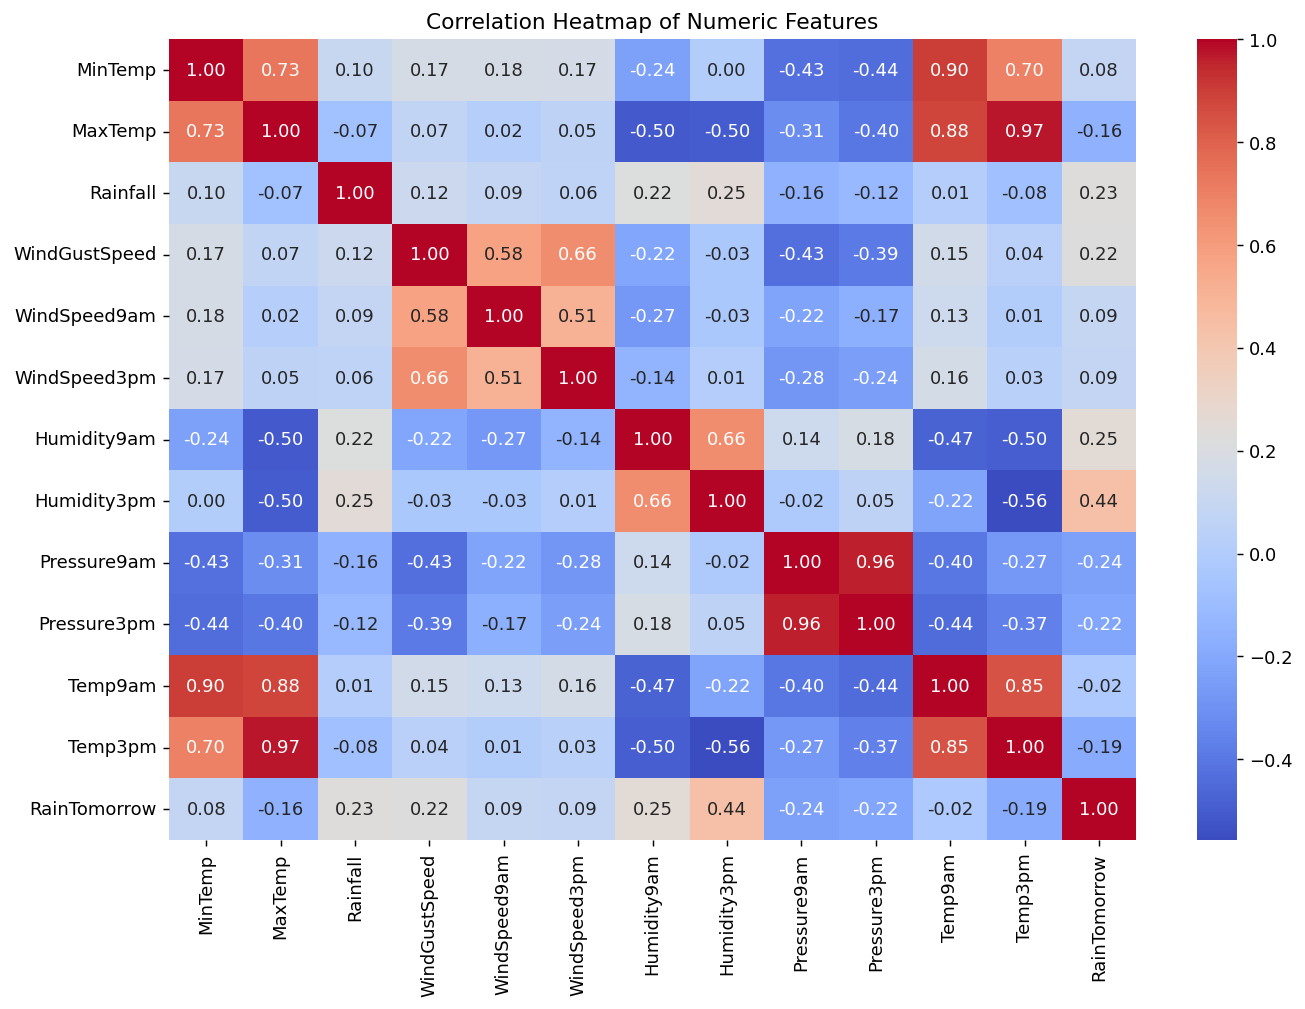


Correlation with RainTomorrow:
RainTomorrow     1.000000
Humidity3pm      0.438609
Humidity9am      0.254422
Rainfall         0.233067
WindGustSpeed    0.223841
WindSpeed9am     0.089472
WindSpeed3pm     0.086015
MinTemp          0.084372
Temp9am         -0.024922
MaxTemp         -0.159310
Temp3pm         -0.190146
Pressure3pm     -0.215979
Pressure9am     -0.235062
Name: RainTomorrow, dtype: float64


In [20]:
import seaborn as sns

# ---------------------------------------------------------
# SELECT ONLY NUMERICAL FEATURES
# Correlation is defined only for numerical variables
# ---------------------------------------------------------
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])

# ---------------------------------------------------------
# COMPUTE CORRELATION MATRIX
# Default method is Pearson correlation
# ---------------------------------------------------------
corr = numeric_df.corr()

# ---------------------------------------------------------
# VISUALIZE CORRELATION MATRIX USING HEATMAP
# annot=True shows correlation values
# fmt=".2f" limits values to 2 decimal places
# ---------------------------------------------------------
plt.figure(figsize=(12, 8), dpi=130)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# ---------------------------------------------------------
# CORRELATION WITH TARGET VARIABLE
# Shows how each feature is linearly related to RainTomorrow
# ---------------------------------------------------------
print("\nCorrelation with RainTomorrow:")
print(corr["RainTomorrow"].sort_values(ascending=False))

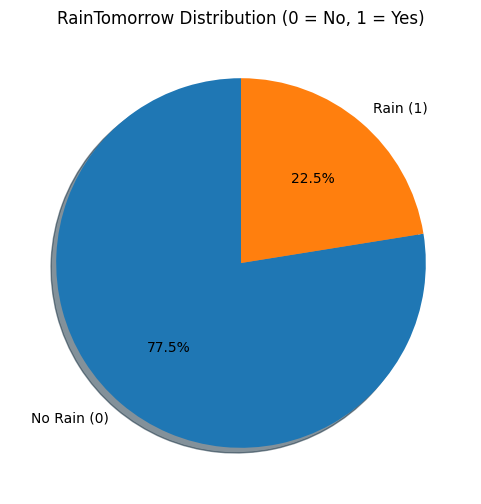

In [21]:

# ---------------------------------------------------------
# COUNT CLASS DISTRIBUTION OF TARGET VARIABLE
# RainTomorrow: 0 = No rain, 1 = Rain
# ---------------------------------------------------------
counts = train_df['RainTomorrow'].value_counts()

# Labels for pie chart
labels = ["No Rain (0)", "Rain (1)"]

# ---------------------------------------------------------
# VISUALIZE CLASS DISTRIBUTION USING PIE CHART
# autopct shows percentage values
# shadow adds depth for better visualization
# startangle rotates chart for better alignment
# ---------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=labels,
    autopct="%.1f%%",
    shadow=True,
    startangle=90
)

# Title for clarity
plt.title("RainTomorrow Distribution (0 = No, 1 = Yes)")

# Display the chart
plt.show()

In [22]:
# Separate target variable
y = train_df["RainTomorrow"]

# Separate all other columns as features
X = train_df.drop(columns=["RainTomorrow"])

In [23]:
# ---------------------------------------------------------
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ---------------------------------------------------------
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# ---------------------------------------------------------
# CREATE PREPROCESSING PIPELINE
# - Numerical features: Standard Scaling
# - Categorical features: One-Hot Encoding
# ---------------------------------------------------------
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# ---------------------------------------------------------
# FIT AND TRANSFORM TRAINING DATA
# fit_transform learns parameters (mean, std, categories)
# ---------------------------------------------------------
X_processed = preprocessor.fit_transform(X)

# ---------------------------------------------------------
# TRANSFORM TEST DATA USING SAME PREPROCESSOR
# Prevents data leakage
# ---------------------------------------------------------
X_test_processed = preprocessor.transform(test_df)

# ---------------------------------------------------------
# CHECK FINAL FEATURE MATRIX SHAPES
# ---------------------------------------------------------
print("Training processed shape:", X_processed.shape)
print("Test processed shape:", X_test_processed.shape)

Training processed shape: (89564, 111)
Test processed shape: (9952, 111)


In [24]:
column_nan_count = train_df.isnull().sum()
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64


In [25]:
# I used to some tips from AI in order to implement Logistic Regression

In [26]:
print("\n=== STARTING LOGISTIC REGRESSION (FROM SCRATCH) ===\n")

# -------------------------------
# Logistic Regression from scratch
# -------------------------------
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=3000):
        self.lr = lr
        self.epochs = epochs

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0

        for _ in range(self.epochs):
            z = X @ self.w + self.b
            y_hat = self.sigmoid(z)

            dw = (X.T @ (y_hat - y)) / n_samples
            db = np.sum(y_hat - y) / n_samples

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_proba(self, X):
        return self.sigmoid(X @ self.w + self.b)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

# -------------------------------
# Train / validation split
# Works for sparse matrices too
# -------------------------------
def train_val_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)

    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)

    split = int(n_samples * (1 - test_size))
    train_idx = indices[:split]
    val_idx = indices[split:]

    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]

# -------------------------------
# Simple evaluation metrics
# -------------------------------
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_scratch(y_true, y_pred):
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TP = np.sum((y_true == 1) & (y_pred == 1))

    return np.array([[TN, FP],
                     [FN, TP]])

def classification_report_scratch(y_true, y_pred):
    cm = confusion_matrix_scratch(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    acc = (TP + TN) / (TP + TN + FP + FN)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))

# -------------------------------
# Model pipeline
# -------------------------------
X_train, X_val, y_train, y_val = train_val_split(
    X_processed, y, test_size=0.2, random_state=42
)

model = LogisticRegressionScratch(lr=0.01, epochs=3000)
model.fit(X_train, y_train)

val_preds = model.predict(X_val)

print("\nValidation results")
print("Accuracy:", accuracy(y_val, val_preds))
print("Confusion matrix:\n", confusion_matrix_scratch(y_val, val_preds))
classification_report_scratch(y_val, val_preds)

# Train on full data
model.fit(X_processed, y)

print("\n=== FINISHED LOGISTIC REGRESSION (FROM SCRATCH) ===\n")



=== STARTING LOGISTIC REGRESSION (FROM SCRATCH) ===


Validation results
Accuracy: 0.8381622285490984
Confusion matrix:
 [[13230   679]
 [ 2220  1784]]
Accuracy : 0.8382
Precision: 0.7243
Recall   : 0.4456
F1-score : 0.5517

=== FINISHED LOGISTIC REGRESSION (FROM SCRATCH) ===



In [27]:
# This code was working very slow. Therefore I used to multithreading for XGBoost( I don't syntax therefore I use AI. 
#I also add tree method( I don't know but it should accelerate the algorithm)

In [ ]:
# One important note: I wrote each model seperately therefore there are some libraries which I import them twice or more

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score
)
from xgboost import XGBClassifier
import numpy as np

print("\n" + "="*60)
print("STARTING XGBOOST MODEL")
print("="*60)

# -------------------------------------------------
# 1. Train / validation split (STRATIFIED)
# -------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------------------------
# 2. Compute class imbalance weight
# -------------------------------------------------
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
scale_pos_weight = neg / pos

print(f"scale_pos_weight used: {scale_pos_weight:.2f}")

# -------------------------------------------------
# 3. Tuned XGBoost model
# -------------------------------------------------
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=4,
    tree_method="hist"
)

# -------------------------------------------------
# 4. Train model
# -------------------------------------------------
xgb.fit(X_train, y_train)

# -------------------------------------------------
# 5. Predict probabilities
# -------------------------------------------------
val_probs = xgb.predict_proba(X_val)[:, 1]

# -------------------------------------------------
# 6. FIND BEST THRESHOLD (BY F1-SCORE)
# -------------------------------------------------
thresholds = np.arange(0.30, 0.60, 0.05)
best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1 = f1_score(y_val, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nBest threshold found: {best_threshold}")
print(f"Best F1-score       : {best_f1:.4f}")

# -------------------------------------------------
# 7. Final validation evaluation
# -------------------------------------------------
val_preds = (val_probs >= best_threshold).astype(int)

print("\nFINAL VALIDATION RESULTS")
print("Accuracy:", accuracy_score(y_val, val_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, val_preds))
print("\nClassification Report:\n", classification_report(y_val, val_preds))

# -------------------------------------------------
# 8. Train final model on FULL data
# -------------------------------------------------
xgb.fit(X_processed, y)

print("="*60)
print("FINISHED XGBOOST MODEL")
print("="*60)



STARTING XGBOOST MODEL
scale_pos_weight used: 3.45

Best threshold found: 0.5499999999999999
Best F1-score       : 0.6638

FINAL VALIDATION RESULTS
Accuracy: 0.835873388042204

Confusion Matrix:
 [[12070  1819]
 [ 1121  2903]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.87      0.89     13889
           1       0.61      0.72      0.66      4024

    accuracy                           0.84     17913
   macro avg       0.76      0.80      0.78     17913
weighted avg       0.85      0.84      0.84     17913

FINISHED XGBOOST MODEL


In [ ]:
# The results were not good , therefore I try to fixed them a little bit

In [29]:
#I don't syntax therefore I use AI.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

print("\n" + "="*60)
print("STARTING KNN MODEL")
print("="*60)

# ----------------------------
# 1. Train-test split
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

# ----------------------------
# 2. Create and train KNN model (MULTI-CORE HERE)
# ----------------------------
knn = KNeighborsClassifier(
    n_neighbors=3,
    n_jobs=4
)

knn.fit(X_train, y_train)

# ----------------------------
# 3. Predict on validation set
# ----------------------------
val_preds = knn.predict(X_val)

# ----------------------------
# 4. Evaluate model
# ----------------------------
print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, val_preds))
print("\nClassification Report:\n", classification_report(y_val, val_preds))

# ----------------------------
# 5. Train final model on full training data
# ----------------------------
knn.fit(X_processed, y)



print("="*60)
print("FINISHED KNN MODEL")
print("="*60)


STARTING KNN MODEL
Validation Accuracy: 0.8181767431474348

Confusion Matrix:
 [[12812  1061]
 [ 2196  1844]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.89     13873
           1       0.63      0.46      0.53      4040

    accuracy                           0.82     17913
   macro avg       0.74      0.69      0.71     17913
weighted avg       0.80      0.82      0.81     17913

FINISHED KNN MODEL


In [31]:
#I don't syntax therefore I use AI for multithreading. I use AI for define Starting and finishing sentences

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*60)
print("STARTING RANDOM FOREST MODEL")
print("="*60)

# ----------------------------
# 1. Train-test split
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

# ----------------------------
# 2. Create and train Random Forest model
# ----------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=4
)

rf.fit(X_train, y_train)

# ----------------------------
# 3. Predict on validation set
# ----------------------------
val_preds = rf.predict(X_val)

# ----------------------------
# 4. Evaluate model
# ----------------------------
print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, val_preds))
print("\nClassification Report:\n", classification_report(y_val, val_preds))

# ----------------------------
# 5. Train final model on full training set
# ----------------------------
rf.fit(X_processed, y)



print("="*60)
print("FINISHED RANDOM FOREST MODEL")
print("="*60)



STARTING RANDOM FOREST MODEL
Validation Accuracy: 0.8196840283592921

Confusion Matrix:
 [[13610   263]
 [ 2967  1073]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.98      0.89     13873
           1       0.80      0.27      0.40      4040

    accuracy                           0.82     17913
   macro avg       0.81      0.62      0.65     17913
weighted avg       0.82      0.82      0.78     17913

FINISHED RANDOM FOREST MODEL


In [ ]:
# One important note: It is possible this model work during long time period. I'm so sorry. And I can't hyperparameter tuning

In [33]:
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("\n" + "="*60)
print("STARTING STACKING MODEL")
print("="*60)

# ----------------------------
# 1. Train-test split
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

# ----------------------------
# 2. Base models (4 CORES)
# ----------------------------
estimators = [
    ('lr', LogisticRegression(
        max_iter=3000,
        solver='saga',
        n_jobs=4
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=4
    )),
    ('xgb', XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=4,
        tree_method='hist'
    ))
]

# ----------------------------
# 3. Stacking model (meta-model, 4 CORES)
# ----------------------------
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        max_iter=3000,
        solver='saga',
        n_jobs=4
    ),
    passthrough=False,
    cv=5,
    n_jobs=4
)

# ----------------------------
# 4. Train stacking model
# ----------------------------
stack_model.fit(X_train, y_train)

# ----------------------------
# 5. Predict validation
# ----------------------------
val_preds = stack_model.predict(X_val)

# ----------------------------
# 6. Evaluate
# ----------------------------
print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, val_preds))
print("\nClassification Report:\n", classification_report(y_val, val_preds))

# ----------------------------
# 7. Train final stacking model
# ----------------------------
stack_model.fit(X_processed, y)


print("="*60)
print("FINISHED STACKING MODEL")
print("="*60)



STARTING STACKING MODEL
Validation Accuracy: 0.8529001283983699

Confusion Matrix:
 [[13122   751]
 [ 1884  2156]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     13873
           1       0.74      0.53      0.62      4040

    accuracy                           0.85     17913
   macro avg       0.81      0.74      0.76     17913
weighted avg       0.84      0.85      0.84     17913

FINISHED STACKING MODEL


In [ ]:
# Also one important note: I wrote these codes for text file result. But requirements changed but I did not change the code


FINAL MODEL COMPARISON
                    Accuracy  Precision  Recall  F1-score
Logistic (Scratch)    0.8382     0.7243  0.4456    0.5517
XGBoost               0.8359     0.6100  0.7200    0.6600
KNN                   0.8182     0.6300  0.4600    0.5300
Random Forest         0.8197     0.8000  0.2700    0.4000
Stacking              0.8529     0.7400  0.5300    0.6200

BEST MODEL (POSITIVE CLASS, F1-SCORE)
Best Model : XGBoost
Best F1    : 0.6600


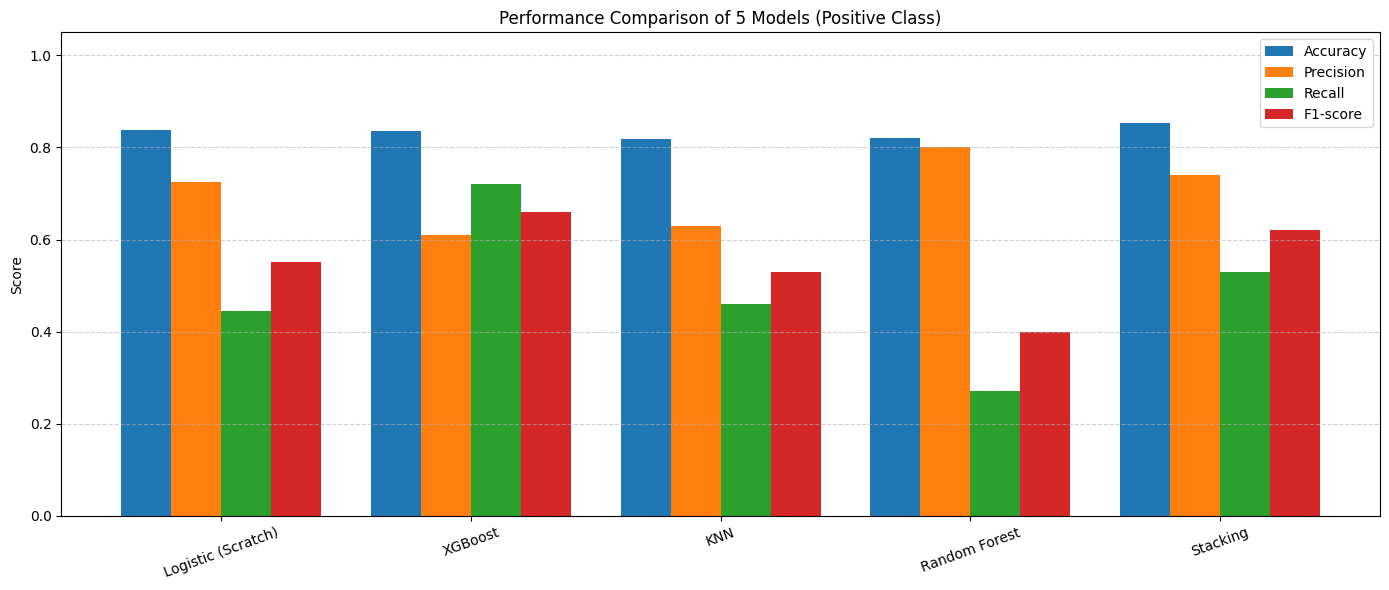

In [42]:
# ============================================================
# FINAL ANALYSIS
# ============================================================
results = {
    "Logistic (Scratch)": {
        "Accuracy": 0.8382,
        "Precision": 0.7243,
        "Recall": 0.4456,
        "F1-score": 0.5517
    },
    "XGBoost": {
        "Accuracy": 0.8359,
        "Precision": 0.61,
        "Recall": 0.72,
        "F1-score": 0.66
    },
    "KNN": {
        "Accuracy": 0.8182,
        "Precision": 0.63,
        "Recall": 0.46,
        "F1-score": 0.53
    },
    "Random Forest": {
        "Accuracy": 0.8197,
        "Precision": 0.80,
        "Recall": 0.27,
        "F1-score": 0.40
    },
    "Stacking": {
        "Accuracy": 0.8529,
        "Precision": 0.74,
        "Recall": 0.53,
        "F1-score": 0.62
    }
}

# ============================================================
# BUILD DATAFRAME
# ============================================================
results_df = pd.DataFrame(results).T

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(results_df)

# ============================================================
# BEST MODEL (BY F1-SCORE)
# ============================================================
best_model = results_df["F1-score"].idxmax()
best_f1 = results_df.loc[best_model, "F1-score"]

print("\n" + "="*60)
print("BEST MODEL (POSITIVE CLASS, F1-SCORE)")
print("="*60)
print(f"Best Model : {best_model}")
print(f"Best F1    : {best_f1:.4f}")

# ============================================================
# VISUALIZATION
# ============================================================
metrics = results_df.columns
models = results_df.index
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(14, 6))

for i, metric in enumerate(metrics):
    plt.bar(x + i * width, results_df[metric], width, label=metric)

plt.xticks(x + width * 1.5, models, rotation=20)
plt.ylabel("Score")
plt.title("Performance Comparison of 5 Models (Positive Class)")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
